In [1]:
# I am going to find the x and y cordinates from the wellbore folder and try to load it on a map


In [1]:
#basics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#itertools
from itertools import product

# plotly and dash
import dash
from dash import dcc, html
import plotly.offline as pyo
import plotly.graph_objs as go
from dash.dependencies import Input, Output
from dash.exceptions import PreventUpdate
import plotly.express as px

#others
from pathlib import Path
import re



## Fetching XY location and making a dataframe

In [2]:
root_dir = Path("../../0_Volve_dataset/13_Well_technical_data")


In [3]:
root_dir

PosixPath('../../0_Volve_dataset/13_Well_technical_data')

In [4]:
fields = [
    "WELL NAME",
    "WELLBORE NAME",
    "Surface EW",
    "Surface NS",
    "Surface Latitude",
    "Surface Longitude",
    "Bottom Hole EW",
    "Bottom Hole NS",
]

In [5]:
patterns = {
    field: re.compile(rf"^{re.escape(field)}:\s*(.+?)\s*$", re.IGNORECASE)
    for field in fields
}

In [6]:
def clean_value(value):
    value = value.strip()
    value = re.sub(r"(?<=\d)\s*m$", "", value, flags=re.IGNORECASE)
    value = re.sub(r"(?<=\d)\s*deg\.?$", "", value, flags=re.IGNORECASE)
    return value.strip()

In [7]:
def get_file_type(file_path):
    name = file_path.name.upper()

    if "ACTUAL" in name:
        return "ACTUAL"
    elif "PLAN" in name:
        return "PLAN"
    else:
        return None

In [8]:
rows = []
for file_path in root_dir.rglob("*"):
    if not file_path.is_file():
        continue

    file_type = get_file_type(file_path)

    # only keep files that have ACTUAL or PLAN in the file name
    if file_type is None:
        continue

    row = {
        "file_path": str(file_path),
        "file_name": file_path.name,
        "plan_or_actual": file_type,
    }

    for field in fields:
        row[field] = None

    try:
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                for field, pattern in patterns.items():
                    match = pattern.match(line)
                    if match:
                        row[field] = clean_value(match.group(1))

    except Exception as e:
        print(f"Could not read {file_path}: {e}")
        continue

    rows.append(row)

df_headers = pd.DataFrame(rows)

numeric_cols = [
    "Surface EW",
    "Surface NS",
    "Bottom Hole EW",
    "Bottom Hole NS",
]

for col in numeric_cols:
    df_headers[col] = pd.to_numeric(df_headers[col], errors="coerce")



df_headers=df_headers[df_headers['Surface EW'].notna()] # make sure the surface location is at least a number
df_headers=df_headers.drop_duplicates(subset=['WELLBORE NAME']) # drop duplicate wellbore names
df_headers["char_count"]=df_headers["WELLBORE NAME"].str.len()  # count and drop rows that have wellbore name more than 15
df_headers= df_headers[df_headers["char_count"] <= 15]
df_headers

Task was destroyed but it is pending!
task: <Task pending name='Task-40' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-41' coro=<Kernel.shell_main() running at /home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Exception ignored in: <coroutine object Kernel.shell_main at 0x7eacfe66b240>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored in: <coroutine object Kernel.shell_main at 0x7eacfe66b240>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destroyed but it is pending!
task: <Task pending name='Task-41' coro=<Kernel.shell

,file_path,file_name,plan_or_actual,WELL NAME,WELLBORE NAME,Surface EW,Surface NS,Surface Latitude,Surface Longitude,Bottom Hole EW,Bottom Hole NS,char_count
1,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_F-2_F-2_F-2 rev#2 STGAL 151015_PLAN,PLAN,F-2,F-2,435047.604,6478564.735,58 26' 29.8447 N,1 53' 14.7783 E,435474.997,6479446.001,3
2,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_F-4_F-4_F4 Rev 016 FinalCoords CC 3107...,PLAN,F-4,F-4,435049.831,6478560.825,58 26' 29.7195 N,1 53' 14.9196 E,435607.290,6477581.186,3
6,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_F-10_F-10_F-10_ACTUAL,ACTUAL,F-10,F-10,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,437989.579,6476538.580,4
9,../../0_Volve_dataset/13_Well_technical_data/W...,F10 Rev 51 280409_PLAN.txt,PLAN,F-10,NO 15/9-F-10,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,438039.045,6476491.728,12
11,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_F-10_F-10 A_F-10 A rev#7 LHULT 171115_...,PLAN,F-10,F-10 A,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,435473.927,6479442.844,6
12,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_F-8_F-8_F8 Volve Sør Prod DRAFT NewRig...,PLAN,F-8,F-8,435050.021,6478563.523,58 26' 29.8068 N,1 53' 14.9285 E,434308.000,6476816.000,3
14,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_F-3_F-3_F-3 rev#1 STGAL 151015_PLAN,PLAN,F-3,F-3,435048.718,6478562.780,58 26' 29.7821 N,1 53' 14.8489 E,435474.997,6479446.001,3
16,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_F-5_F-5_F-5_ACTUAL,ACTUAL,F-5,F-5,435050.945,6478558.870,58 26' 29.6569 N,1 53' 14.9902 E,436403.365,6478703.521,3
21,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_F-13_F-13_F-13 Main field rev#5 STGAL ...,PLAN,F-13,F-13,435051.324,6478564.265,58 26' 29.8315 N,1 53' 15.0081 E,436430.999,6478725.001,4
22,../../0_Volve_dataset/13_Well_technical_data/W...,Volve F_Relief well location 4_F-1 C_F-1 C Rel...,PLAN,Relief well location 4,F-1 C,435030.000,6477220.000,58 25' 46.3658 N,1 53' 15.0647 E,434901.300,6478814.400,5


## Using Plotly to make XY map

### Plotting the XY well coordinates on the world map

In [9]:
# select the columns needed from the df_headers
df_XY=df_headers[['WELL NAME',
       'WELLBORE NAME', 'Surface EW', 'Surface NS', 'Surface Latitude',
       'Surface Longitude', 'Bottom Hole EW', 'Bottom Hole NS']]
df_XY

,WELL NAME,WELLBORE NAME,Surface EW,Surface NS,Surface Latitude,Surface Longitude,Bottom Hole EW,Bottom Hole NS
1,F-2,F-2,435047.604,6478564.735,58 26' 29.8447 N,1 53' 14.7783 E,435474.997,6479446.001
2,F-4,F-4,435049.831,6478560.825,58 26' 29.7195 N,1 53' 14.9196 E,435607.290,6477581.186
6,F-10,F-10,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,437989.579,6476538.580
9,F-10,NO 15/9-F-10,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,438039.045,6476491.728
11,F-10,F-10 A,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,435473.927,6479442.844
12,F-8,F-8,435050.021,6478563.523,58 26' 29.8068 N,1 53' 14.9285 E,434308.000,6476816.000
14,F-3,F-3,435048.718,6478562.780,58 26' 29.7821 N,1 53' 14.8489 E,435474.997,6479446.001
16,F-5,F-5,435050.945,6478558.870,58 26' 29.6569 N,1 53' 14.9902 E,436403.365,6478703.521
21,F-13,F-13,435051.324,6478564.265,58 26' 29.8315 N,1 53' 15.0081 E,436430.999,6478725.001
22,Relief well location 4,F-1 C,435030.000,6477220.000,58 25' 46.3658 N,1 53' 15.0647 E,434901.300,6478814.400


In [10]:
df_XY.info()

<class 'pandas.DataFrame'>
Index: 28 entries, 1 to 102
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   WELL NAME          28 non-null     str    
 1   WELLBORE NAME      28 non-null     str    
 2   Surface EW         28 non-null     float64
 3   Surface NS         28 non-null     float64
 4   Surface Latitude   28 non-null     str    
 5   Surface Longitude  28 non-null     str    
 6   Bottom Hole EW     28 non-null     float64
 7   Bottom Hole NS     28 non-null     float64
dtypes: float64(4), str(4)
memory usage: 2.0 KB


In [11]:
# change DMS to decimal
import re

def dms_to_dd(dms_str):
    # extract numbers
    parts = re.findall(r"[\d.]+", dms_str)
    degrees, minutes, seconds = map(float, parts)

    # extract direction (N, S, E, W)
    direction = re.search(r"[NSEW]", dms_str).group()

    dd = degrees + minutes/60 + seconds/3600

    if direction in ["S", "W"]:
        dd *= -1

    return dd

In [12]:
#Apply DMS to the df_XY dataframe
df_XY["lat_dd"] = df_XY["Surface Latitude"].apply(dms_to_dd)
df_XY["lon_dd"] = df_XY["Surface Longitude"].apply(dms_to_dd)
df_XY

,WELL NAME,WELLBORE NAME,Surface EW,Surface NS,Surface Latitude,Surface Longitude,Bottom Hole EW,Bottom Hole NS,lat_dd,lon_dd
1,F-2,F-2,435047.604,6478564.735,58 26' 29.8447 N,1 53' 14.7783 E,435474.997,6479446.001,58.441624,1.887438
2,F-4,F-4,435049.831,6478560.825,58 26' 29.7195 N,1 53' 14.9196 E,435607.290,6477581.186,58.441589,1.887478
6,F-10,F-10,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,437989.579,6476538.580,58.441578,1.887519
9,F-10,NO 15/9-F-10,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,438039.045,6476491.728,58.441578,1.887519
11,F-10,F-10 A,435052.248,6478559.613,58 26' 29.6816 N,1 53' 15.0698 E,435473.927,6479442.844,58.441578,1.887519
12,F-8,F-8,435050.021,6478563.523,58 26' 29.8068 N,1 53' 14.9285 E,434308.000,6476816.000,58.441613,1.887480
14,F-3,F-3,435048.718,6478562.780,58 26' 29.7821 N,1 53' 14.8489 E,435474.997,6479446.001,58.441606,1.887458
16,F-5,F-5,435050.945,6478558.870,58 26' 29.6569 N,1 53' 14.9902 E,436403.365,6478703.521,58.441571,1.887497
21,F-13,F-13,435051.324,6478564.265,58 26' 29.8315 N,1 53' 15.0081 E,436430.999,6478725.001,58.441620,1.887502
22,Relief well location 4,F-1 C,435030.000,6477220.000,58 25' 46.3658 N,1 53' 15.0647 E,434901.300,6478814.400,58.429546,1.887518


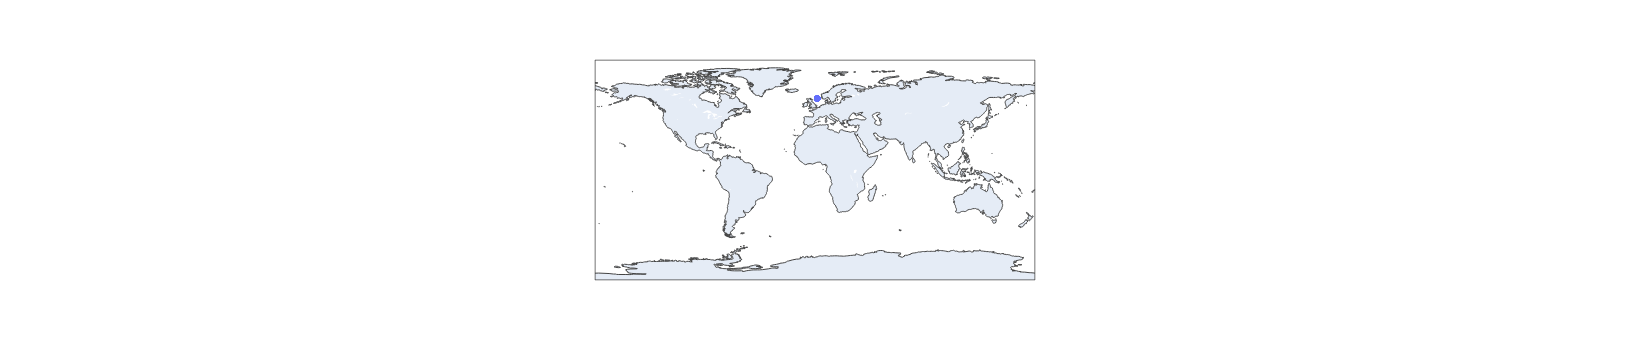

In [13]:
fig = px.scatter_geo(
    df_XY,
    lat="lat_dd",
    lon="lon_dd",
    hover_name="WELLBORE NAME",
)


fig.show()

### Plotting the polygon on the world map

In [17]:
#load and convert the Hugin base polygon to a dataframe

file_path = Path("../../0_Volve_dataset/2_Geophysical_Interpretations/Fault_polygons/2014_Volve_Hugin_Base.dat")

rows = []
current_polygon = None
expected_points = None
reading_points = False

with open(file_path, "r", errors="ignore") as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].rstrip()

    if line.startswith("Mapping Polygon"):
        parts = line.split()
        current_polygon = parts[-1]   # polygon sequence number
        reading_points = False

        # next line contains number of points
        i += 1
        info_line = lines[i].split()
        expected_points = int(info_line[2])

        reading_points = True
        point_count = 0

    elif reading_points and line.strip():
        parts = line.split()

        if len(parts) == 3:
            x, y, z = map(float, parts)

            rows.append({
                "polygon_id": current_polygon,
                "point_order": point_count + 1,
                "x": x,
                "y": y,
                "z": z
            })

            point_count += 1

            if point_count >= expected_points:
                reading_points = False

    i += 1

df_poly = pd.DataFrame(rows)

df_poly

,polygon_id,point_order,x,y,z
0,71,1,435259.53,6479503.5,2714.235352
1,71,2,435219.94,6479501.0,2706.789307
2,71,3,435181.06,6479502.0,2710.512207
3,71,4,435163.38,6479498.5,2712.498047
4,71,5,435115.31,6479473.0,2708.030273
...,...,...,...,...,...
1495,0,8,436859.97,6479294.0,2804.401123
1496,0,9,436772.91,6479190.0,2807.272949
1497,0,10,436700.34,6479132.0,2805.930420
1498,0,11,436668.19,6479116.5,2756.585205


In [18]:
# covert polgyon coordinate to world map
from pyproj import Transformer

# ED50 / UTM Zone 31N -> WGS84 lat/lon
transformer = Transformer.from_crs(
    "EPSG:23031",
    "EPSG:4326",
    always_xy=True
)

df_poly["lon"], df_poly["lat"] = transformer.transform(
    df_poly["x"].values,
    df_poly["y"].values
)

df_poly.head()

,polygon_id,point_order,x,y,z,lon,lat
0,71,1,435259.53,6479503.5,2714.235352,1.889208,58.449470
1,71,2,435219.94,6479501.0,2706.789307,1.888530,58.449442
2,71,3,435181.06,6479502.0,2710.512207,1.887864,58.449445
3,71,4,435163.38,6479498.5,2712.498047,1.887562,58.449411
4,71,5,435115.31,6479473.0,2708.030273,1.886746,58.449175


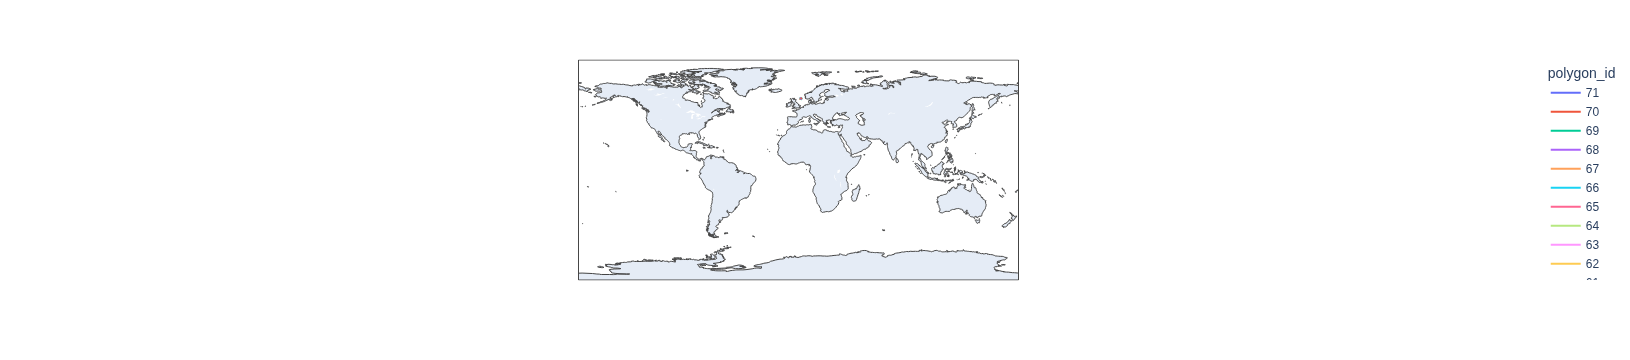

In [19]:
fig = px.line_geo(
    df_poly,
    lat="lat",
    lon="lon",
    color="polygon_id",
)

fig.show()

### Plot the polgyon and the wellbore xy on the world map

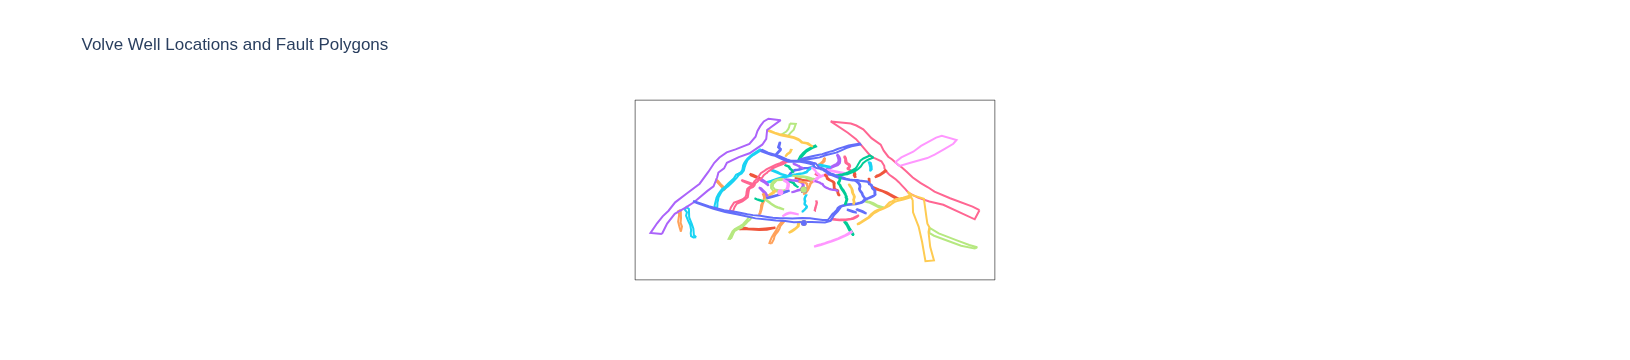

In [20]:


# make traces for polgy and xy coordinate
fig_poly =px.line_geo(df_poly,lat="lat",lon="lon", color="polygon_id")
fig_wells = px.scatter_geo(df_XY,lat="lat_dd",lon="lon_dd",hover_name="WELLBORE NAME", color="WELLBORE NAME")

fig = go.Figure()

# add polygon traces
for trace in fig_poly.data:
    fig.add_trace(trace)

# add well traces
for trace in fig_wells.data:
    fig.add_trace(trace)

fig.update_layout(title="Volve Well Locations and Fault Polygons",hovermode="closest",showlegend=False)
fig.update_geos(fitbounds="locations",visible=True)

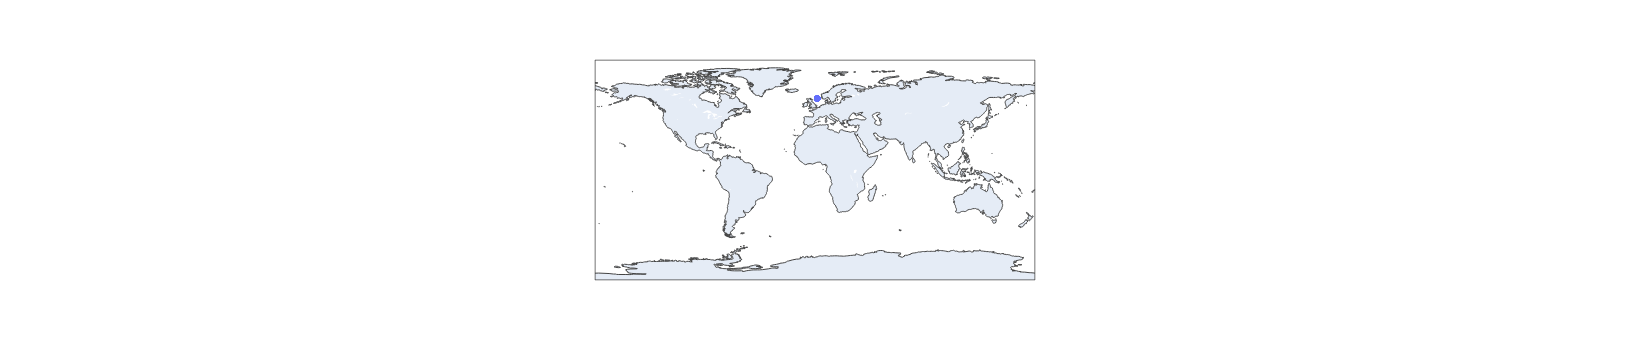

In [21]:
fig = px.scatter_geo(
    df_XY,
    lat="lat_dd",
    lon="lon_dd",
    hover_name="WELLBORE NAME",
)


fig.show()